In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

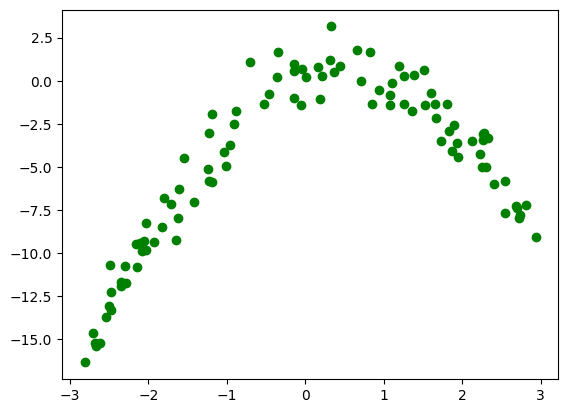

In [2]:
# we creating suitable dataset and quadratic dataset is best option

x=6* np.random.rand(100,1)-3
y=-1.5 * x**2 +1.5*x +np.random.randn(100,1)
plt.scatter(x,y,color='g')

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
regression1=LinearRegression()


In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [7]:
x_train_poly

array([[ 1.00000000e+00, -2.35016680e+00,  5.52328401e+00],
       [ 1.00000000e+00,  7.08585838e-01,  5.02093890e-01],
       [ 1.00000000e+00, -1.01187744e+00,  1.02389596e+00],
       [ 1.00000000e+00,  1.58139865e-01,  2.50082169e-02],
       [ 1.00000000e+00,  2.67990105e+00,  7.18186964e+00],
       [ 1.00000000e+00,  4.42173125e-01,  1.95517072e-01],
       [ 1.00000000e+00,  1.07528049e+00,  1.15622813e+00],
       [ 1.00000000e+00, -2.34662056e+00,  5.50662805e+00],
       [ 1.00000000e+00,  9.40659604e-01,  8.84840490e-01],
       [ 1.00000000e+00,  1.86453894e+00,  3.47650545e+00],
       [ 1.00000000e+00, -1.82891868e+00,  3.34494352e+00],
       [ 1.00000000e+00,  1.73377879e+00,  3.00598891e+00],
       [ 1.00000000e+00, -2.03403527e+00,  4.13729947e+00],
       [ 1.00000000e+00, -1.48502968e-01,  2.20531315e-02],
       [ 1.00000000e+00, -3.60279591e-01,  1.29801383e-01],
       [ 1.00000000e+00,  1.07861411e+00,  1.16340841e+00],
       [ 1.00000000e+00, -2.81219929e+00

In [8]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
y_pred=regression.predict(x_test_poly)
score=r2_score(y_test,y_pred)
print(score)


0.9451439863006363


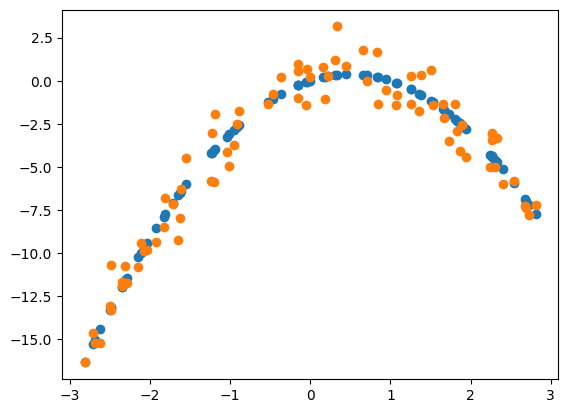

In [9]:
plt.scatter(x_train,regression.predict(x_train_poly))
plt.scatter(x_train,y_train)

In [10]:
#prediction of new data
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
x_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

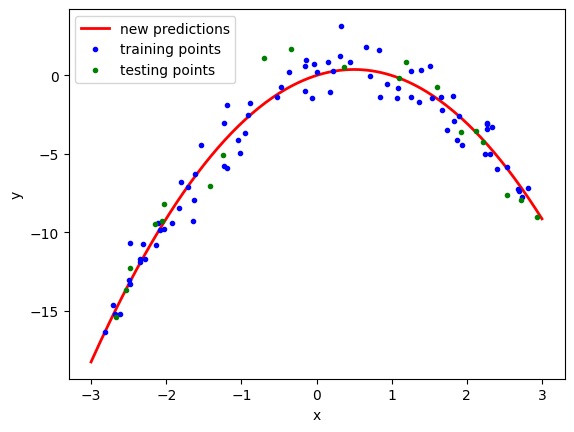

In [11]:
y_new=regression.predict(x_new_poly)
plt.plot(x_new,y_new,"r",linewidth=2,label="new predictions")
plt.plot(x_train,y_train,"b.",label='training points')
plt.plot(x_test,y_test,"g.",label='testing points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [13]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(x_train_poly, y_train)
y_pred = regression.predict(x_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9451439863006363


## Pipeline Concepts

In [14]:
from sklearn.pipeline import Pipeline

In [25]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(x_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()


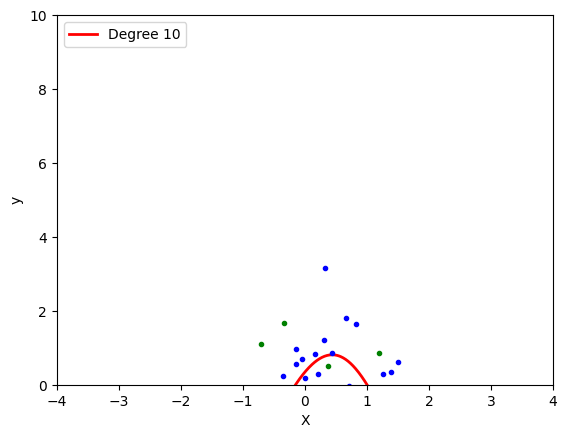

In [26]:
poly_regression(10)